## Ejercicio 1: Evaluación de solicitud de crédito bancario
Problema: un sistema evalúa automáticamente una solicitud de crédito, considerando:
- ingreso_mensual: un número (en soles)
- monto_solicitado: un número (en soles)
- tiene_historial_moroso: True o False
  
El sistema debe calcular la relación entre el monto solicitado y el ingreso mensual (monto_solicitado
/ ingreso_mensual), y usar esa relación junto con el historial para decidir si aprueba, aprueba con
condiciones, o rechaza la solicitud.

### Ficha PEAS
| Elemento | Descripción |
|---|---|
| **Percepción (S)** | Ingreso mensual del solicitante, monto solicitado y el historial de morosidad. |
| **Acciones (A)** | Aprobar la solicitud, aprobar con condiciones o rechazar la solicitud. |
| **Entorno (E)** | Sistema bancario encargado de evaluar solicitudes de crédito de diferentes clientes. |
| **Objetivo** | Evaluar las solicitudes de un usuario evitando riesgos de otorgar creditos que no pueda pagar o generar incumplimientos |
| **Medida de desempeño (P)** | Aprobar solicitudes que su puedan a llegar cumplirse y rechazar aquellas que presenten riesgo de incumplimiento. |

### Justificación de las reglas
Para evaluar la solicitud como bien menciona el ejercicio se utilizara la relacion entre el monto solicitado y el ingreso mensual del usuario o cliente. Para ello se considerara las siguientes reglas para poder evaluar:
- si la relacion es menor o igual que 0.30 y el cliente no presenta un historial moroso, entonces se le dara por **aprobado**.
- Si la relacion es mayor a 0.30 pero menor o igual a 0.50 y no presenta un historial moroso, entonces se le aprobada con **condiciones**.
- Si la relacion es mayor a 0.50, entonces la solicitud sera **rechazada** ya que el monto solicitado es muy alto.

#### Ejemplo:
si un cliente gana 5000 y solicita un monto de 3500:

1200 / 4000 = 0.3

Entonces la relacion es 0.3, quiere decir que equivale al 30% de su ingreso mensual.

Y asi de la misma manera para todas las reglas mencionadas

### Código
Para esto punto vamos hacer una funcion la cual nos permitira calcular la relacion entre el monto solicitado y el ingreso mensual del cliente. Una ves calculado la relacion, esta evaluara junto con el historial de morosidad para decidir si la solicitudad se aprueba, se aprueba con condiciones o si se rechaza.

Una vez realizado el calculo, el resultado nos debe mostrar una tupla formada por la accion y el motivo de la desicion.

In [28]:
def agente_credito(ingreso_mensual, monto_solicitado, tiene_historial_moroso):
    relacion = monto_solicitado / ingreso_mensual

    ## Cliente con historial moroso
    if tiene_historial_moroso:
        if relacion <= 0.30:
            return (
                "Aprobar la solicitud con condiciones",
                f" La relación es de {relacion:.2f} con historial moroso")
        else:
            return (
                "Rechazar solicitud",
                f" La relación es de {relacion:.2f} con historial moroso")

    ## Cliente sin historial moroso
    else:
        if relacion <= 0.30:
            return (
                "Aprobar solicitud",
                f"La relación es de de {relacion: .2f} y sin historial moroso")

        elif relacion <= 0.50:
            return (
                "Aprobar solicitud pero con condiciones",
                f"La relación es de {relacion: .2f} considerada intermedia")
        else:
            return (
                "Rechazar solicitud",
                f"La relación es de {relacion: .2f} superior a 0.50")
            


        

### Simulación y pruebas

Para simular y hacer las pruebas se realizara diferentes pruebas para ver los distintos resultados.

In [29]:
# Pruebas:

pruebas = [
    (4000, 1000, False),   # relación 0.25 -> aprobar
    (4000, 1200, False),   # relación 0.30 -> caso límite
    (4000, 1600, False),   # relación 0.40 -> aprobar con condiciones
    (4000, 2400, False),   # relación 0.60 -> rechazar
    (5000, 1000, True),    # relación 0.20 + moroso -> aprobar con condiciones
    (5000, 2000, True)     # relación 0.40 + moroso -> rechazar
]

for ingreso, monto, moroso in pruebas:
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, moroso)

    print(f"Ingreso: S/ {ingreso} | " f"Monto solicitado: S/ {monto} | "  f"Relación: {relacion:.2f} | " f"Historial moroso: {moroso}")
    print(f"Decisión: {accion}")
    print(f"Motivo: {motivo}")
    print("-" * 100)

Ingreso: S/ 4000 | Monto solicitado: S/ 1000 | Relación: 0.25 | Historial moroso: False
Decisión: Aprobar solicitud
Motivo: La relación es de de  0.25 y sin historial moroso
----------------------------------------------------------------------------------------------------
Ingreso: S/ 4000 | Monto solicitado: S/ 1200 | Relación: 0.30 | Historial moroso: False
Decisión: Aprobar solicitud
Motivo: La relación es de de  0.30 y sin historial moroso
----------------------------------------------------------------------------------------------------
Ingreso: S/ 4000 | Monto solicitado: S/ 1600 | Relación: 0.40 | Historial moroso: False
Decisión: Aprobar solicitud pero con condiciones
Motivo: La relación es de  0.40 considerada intermedia
----------------------------------------------------------------------------------------------------
Ingreso: S/ 4000 | Monto solicitado: S/ 2400 | Relación: 0.60 | Historial moroso: False
Decisión: Rechazar solicitud
Motivo: La relación es de  0.60 superior

### Visualización

Para poder observar todo el resultado en un escenario donde hay muchos casos de prestamos, vamos a generar 200 solicitudes de creditos aleatorias donde:
- Cada solicitud tendrea un ingreso mensual, un monto y un historial de morosidad
- cada solicitud sera evaludad por el sistema y mostrara un grafico
- en el grafico que va generar, el eje X representara la relacion entre el monto solicitado y el ingreso mensual. Y para el eje Y representara el ingreso mensual.

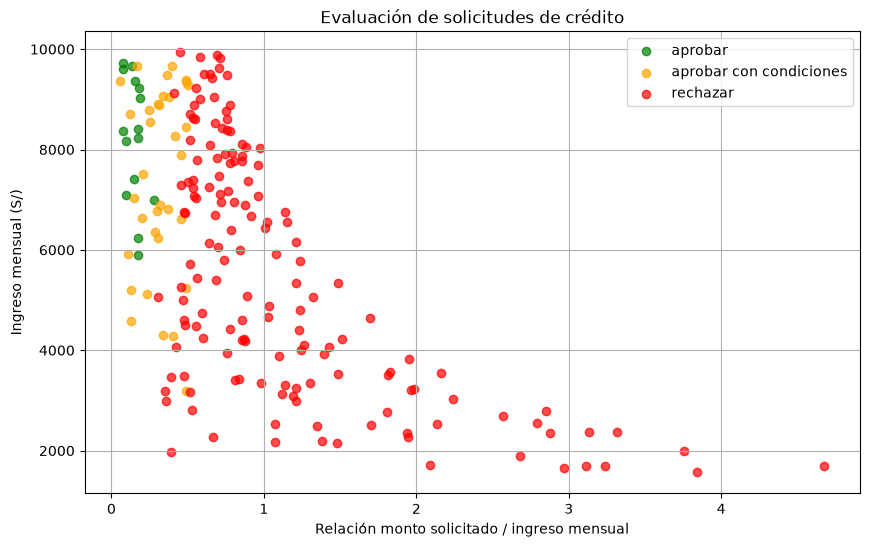

In [32]:
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(42)

n = 200

# Generación de solicitudes aleatorias
ingresos = np.random.randint(1500, 10000, n)
montos = np.random.randint(500, 8000, n)
historial_moroso = np.random.choice([True, False], size=n)

relaciones = []
decisiones = []

for ingreso, monto, moroso in zip(ingresos, montos, historial_moroso):
    relacion = monto / ingreso
    accion, motivo = agente_credito(ingreso, monto, moroso)

    relaciones.append(relacion)

    # Organizar las diferentes respuestas del agente
    accion = accion.lower()

    if "rechazar" in accion:
        decisiones.append("rechazar")

    elif "condiciones" in accion:
        decisiones.append("aprobar con condiciones")

    else:
        decisiones.append("aprobar")


# Colores para cada decisión
colores = {
    "aprobar": "green",
    "aprobar con condiciones": "orange",
    "rechazar": "red"
}

plt.figure(figsize=(10, 6))

for decision in colores:

    indices = [
        i for i, d in enumerate(decisiones)
        if d == decision
    ]

    plt.scatter(
        [relaciones[i] for i in indices],
        [ingresos[i] for i in indices],
        label=decision,
        color=colores[decision],
        alpha=0.7
    )

plt.title("Evaluación de solicitudes de crédito")
plt.xlabel("Relación monto solicitado / ingreso mensual")
plt.ylabel("Ingreso mensual (S/)")
plt.legend()
plt.grid(True)

plt.show()